# PhysicsNeMo Motor FEM Training (MeshGraphNet)

? ???? `MagTransient_*.txt`? ??? ??? ???? ???,
`physicsnemo.models.meshgraphnet.MeshGraphNet`?? `Bx, By`? ?????.

?? ?? ??: Docker ???? ?? (`friendly_knuth`)


In [1]:
import os
import re
from collections import defaultdict

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from physicsnemo.models.meshgraphnet import MeshGraphNet

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('device count:', torch.cuda.device_count())


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
torch: 2.10.0a0+a36e1d39eb.nv26.01.42222806
cuda available: True
device count: 1


/usr/local/lib/python3.12/dist-packages/torch/library.py:357: UserWarning: Warning only once for all operators,  other operators may also be overridden.
  Overriding a previously registered kernel for the same operator and the same dispatch key
  operator: flash_attn::_flash_attn_backward(Tensor dout, Tensor q, Tensor k, Tensor v, Tensor out, Tensor softmax_lse, Tensor(a6!)? dq, Tensor(a7!)? dk, Tensor(a8!)? dv, float dropout_p, float softmax_scale, bool causal, SymInt window_size_left, SymInt window_size_right, float softcap, Tensor? alibi_slopes, bool deterministic, Tensor? rng_state=None) -> Tensor
    registered at /usr/local/lib/python3.12/dist-packages/torch/_library/custom_ops.py:926
  dispatch key: ADInplaceOrView
  previous kernel: no debug info
       new kernel: registered at /usr/local/lib/python3.12/dist-packages/torch/_library/custom_ops.py:926 (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/core/dispatch/OperatorEntry.cpp:208.)
  self.m.impl(


In [2]:
DATA_PATH = '/workspace/data/MagTransient_20260130_152245.txt'
# DATA_PATH = '/workspace/MagTransient_20260130_152245.txt'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f'{DATA_PATH} not found. ??? ????? ?? ? ?? ?????.\n'
        '?: docker cp D:/KDH/NvidiaNemo/Project/MagTransient_20260130_152245.txt friendly_knuth:/workspace/data/'
    )

print('DATA_PATH:', DATA_PATH)


DATA_PATH: /workspace/data/MagTransient_20260130_152245.txt


# _parse_solution_header

In [3]:
def _parse_solution_header(line):
    m = re.search(r'^10\s+Solution\s+(\d+)(.*)$', line.strip())
    if not m:
        return None
    idx = int(m.group(1))
    rest = m.group(2)

    time_val = 0.0
    rot_step = 0.0
    m_time = re.search(r'Time\s+([-+0-9.Ee]+)', rest)
    m_rot = re.search(r'Rotate\s+Step\s+([-+0-9.Ee]+)', rest)
    if m_time:
        time_val = float(m_time.group(1))
    if m_rot:
        rot_step = float(m_rot.group(1))
    return idx, time_val, rot_step


def parse_magtransient_file(path):
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    solutions = []
    i = 0
    n = len(lines)

    while i < n:
        h = _parse_solution_header(lines[i])
        if h is None:
            i += 1
            continue

        sol_idx, time_val, rot_step = h
        i += 1

        while i < n and 'ElementsTable' not in lines[i]:
            i += 1
        if i >= n:
            break
        i += 1

        while i < n and '--------' not in lines[i]:
            i += 1
        i += 1

        elems = []
        while i < n:
            s = lines[i].strip()
            if not s:
                i += 1
                continue
            if 'NodesTable' in s or s.startswith('10 Solution'):
                break
            if re.match(r'^\d+\s*,', s):
                parts = [p.strip() for p in s.split(',')]
                if len(parts) >= 9:
                    elems.append([
                        int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3]),
                        int(parts[4]), float(parts[5]), float(parts[6]),
                        float(parts[7]), float(parts[8])
                    ])
            i += 1

        while i < n and 'NodesTable' not in lines[i]:
            if _parse_solution_header(lines[i]) is not None:
                break
            i += 1

        nodes = []
        if i < n and 'NodesTable' in lines[i]:
            i += 1
            while i < n and '--------' not in lines[i]:
                i += 1
            i += 1

            while i < n:
                s = lines[i].strip()
                if not s:
                    i += 1
                    continue
                if s.startswith('3 ') and 'RegionsTable' in s:
                    break
                if _parse_solution_header(s) is not None:
                    break
                if re.match(r'^\d+\s*,', s):
                    parts = [p.strip() for p in s.split(',')]
                    if len(parts) >= 4:
                        nodes.append([int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])])
                i += 1

        if len(elems) > 0 and len(nodes) > 0:
            solutions.append({
                'solution_index': sol_idx,
                'time': time_val,
                'rot_step': rot_step,
                'elements': np.array(elems, dtype=np.float64),
                'nodes': np.array(nodes, dtype=np.float64),
            })

    return solutions


solutions = parse_magtransient_file(DATA_PATH)
print('num_solutions:', len(solutions))
print('solution[0] elements:', solutions[0]['elements'].shape, 'nodes:', solutions[0]['nodes'].shape)


num_solutions: 45
solution[0] elements: (11330, 9) nodes: (5874, 4)


In [10]:
# === 데이터 구조 확인 ===
print(f'총 솔루션(타임스텝) 수: {len(solutions)}')
print()
for i, sol in enumerate(solutions):
    print(f'  step {i:2d} | sol_idx={sol["solution_index"]:3d} | '
          f'time={sol["time"]:.6e} | rot_step={sol["rot_step"]:.4f} | '
          f'nodes={sol["nodes"].shape[0]} | elems={sol["elements"].shape[0]}')

# 시간 간격, 회전 간격 확인
times = np.array([s['time'] for s in solutions])
rots = np.array([s['rot_step'] for s in solutions])
print(f'\ntime range: {times.min():.6e} ~ {times.max():.6e}')
print(f'rot_step range: {rots.min():.4f} ~ {rots.max():.4f}')
if len(times) > 1:
    dt = np.diff(times)
    dr = np.diff(rots)
    print(f'dt (mean): {dt.mean():.6e}, dr (mean): {dr.mean():.4f}')

# y(Bx,By) 분포 확인
all_y = np.concatenate([g.y.cpu().numpy() for g in graphs], axis=0)
print(f'\ny (Bx,By) 전체 | shape: {all_y.shape}')
print(f'  mean: {all_y.mean(axis=0)}')
print(f'  std:  {all_y.std(axis=0)}')
print(f'  min:  {all_y.min(axis=0)}')
print(f'  max:  {all_y.max(axis=0)}')
print(f'  |B| range: {np.linalg.norm(all_y, axis=1).min():.6f} ~ {np.linalg.norm(all_y, axis=1).max():.6f}')


총 솔루션(타임스텝) 수: 45

  step  0 | sol_idx=  1 | time=0.000000e+00 | rot_step=0.0000 | nodes=5874 | elems=11330
  step  1 | sol_idx=  2 | time=2.777778e-05 | rot_step=-2.0000 | nodes=5882 | elems=11330
  step  2 | sol_idx=  3 | time=5.555556e-05 | rot_step=-2.0000 | nodes=5890 | elems=11330
  step  3 | sol_idx=  4 | time=8.333333e-05 | rot_step=-2.0000 | nodes=5899 | elems=11330
  step  4 | sol_idx=  5 | time=1.111111e-04 | rot_step=-2.0000 | nodes=5907 | elems=11330
  step  5 | sol_idx=  6 | time=1.388889e-04 | rot_step=-2.0000 | nodes=5915 | elems=11330
  step  6 | sol_idx=  7 | time=1.666667e-04 | rot_step=-2.0000 | nodes=5923 | elems=11330
  step  7 | sol_idx=  8 | time=1.944444e-04 | rot_step=-2.0000 | nodes=5932 | elems=11330
  step  8 | sol_idx=  9 | time=2.222222e-04 | rot_step=-2.0000 | nodes=5940 | elems=11330
  step  9 | sol_idx= 10 | time=2.500000e-04 | rot_step=-2.0000 | nodes=5948 | elems=11330
  step 10 | sol_idx= 11 | time=2.777778e-04 | rot_step=-2.0000 | nodes=5956 | elem

In [11]:
# 요약 통계만
print(f'총 스텝: {len(solutions)}')
print(f'time: {times[0]:.6e} → {times[-1]:.6e}, dt≈{np.diff(times).mean():.6e}')
print(f'rot:  {rots[0]:.4f} → {rots[-1]:.4f}, dr≈{np.diff(rots).mean():.4f}')
print(f'노드/스텝: {solutions[0]["nodes"].shape[0]}, 요소/스텝: {solutions[0]["elements"].shape[0]}')
print(f'y std: {all_y.std(axis=0)}, y |B| max: {np.linalg.norm(all_y,axis=1).max():.4f}')
print(f'현재 train/val 분할: {n_train}/{n_total - n_train} (순차)')


총 스텝: 45
time: 0.000000e+00 → 1.222222e-03, dt≈2.777778e-05
rot:  0.0000 → -2.0000, dr≈-0.0455
노드/스텝: 5874, 요소/스텝: 11330
y std: [0.70504665 0.7838479 ], y |B| max: 2.8067
현재 train/val 분할: 36/9 (순차)


build_graph_from_solution

In [12]:
# ============================================================
# 1단계: 정규화 없이 raw 그래프를 먼저 생성
# ============================================================
def build_graph_raw(sol):
    """정규화 전 raw 피처/타깃으로 그래프를 생성한다."""
    nodes = sol['nodes']
    elems = sol['elements']

    node_ids = nodes[:, 0].astype(np.int64)
    pos = nodes[:, 1:3].astype(np.float32)
    A_node = nodes[:, 3].astype(np.float32)
    id_to_idx = {nid: i for i, nid in enumerate(node_ids)}

    tri_nodes = elems[:, 1:4].astype(np.int64)
    reg = elems[:, 4].astype(np.int64)
    bx = elems[:, 5].astype(np.float32)
    by = elems[:, 6].astype(np.float32)

    sum_b = np.zeros((len(node_ids), 2), dtype=np.float32)
    cnt_b = np.zeros((len(node_ids), 1), dtype=np.float32)
    reg_votes = defaultdict(list)

    edges = set()
    for t in range(tri_nodes.shape[0]):
        try:
            i0 = id_to_idx[int(tri_nodes[t, 0])]
            i1 = id_to_idx[int(tri_nodes[t, 1])]
            i2 = id_to_idx[int(tri_nodes[t, 2])]
        except KeyError:
            continue

        tri = [i0, i1, i2]
        for u in tri:
            sum_b[u, 0] += bx[t]
            sum_b[u, 1] += by[t]
            cnt_b[u, 0] += 1.0
            reg_votes[u].append(int(reg[t]))

        for a, b in [(i0, i1), (i1, i2), (i2, i0)]:
            edges.add((a, b))
            edges.add((b, a))

    cnt_b = np.clip(cnt_b, 1.0, None)
    y = sum_b / cnt_b  # (N, 2)  Bx, By

    node_reg = np.zeros((len(node_ids),), dtype=np.float32)
    for i in range(len(node_ids)):
        if reg_votes[i]:
            vals, counts = np.unique(np.array(reg_votes[i]), return_counts=True)
            node_reg[i] = float(vals[np.argmax(counts)])

    tval = float(sol['time'])
    rstep = float(sol['rot_step'])
    # x: [pos_x, pos_y, A, region, time, rot_step]
    x = np.concatenate([
        pos,
        A_node[:, None],
        node_reg[:, None],
        np.full((len(node_ids), 1), tval, dtype=np.float32),
        np.full((len(node_ids), 1), rstep, dtype=np.float32),
    ], axis=1).astype(np.float32)

    edge_list = sorted(list(edges))
    edge_index = np.array(edge_list, dtype=np.int64).T
    src, dst = edge_index[0], edge_index[1]
    dxy = pos[dst] - pos[src]
    dist = np.linalg.norm(dxy, axis=1, keepdims=True)
    edge_attr = np.concatenate([dxy, dist], axis=1).astype(np.float32)

    return Data(
        x=torch.from_numpy(x),
        y=torch.from_numpy(y),
        edge_index=torch.from_numpy(edge_index),
        edge_attr=torch.from_numpy(edge_attr),
        pos=torch.from_numpy(pos),
    )


raw_graphs = [build_graph_raw(sol) for sol in solutions]
print(f'raw graphs: {len(raw_graphs)}')
print(f'x: {raw_graphs[0].x.shape}, y: {raw_graphs[0].y.shape}, edge_attr: {raw_graphs[0].edge_attr.shape}')


# ============================================================

# 2단계: 전체 45스텝에 대한 **글로벌** 정규화 통계 계산print(f'time feature — step 0: {t_feat_first:.4f}, step {len(graphs)-1}: {t_feat_last:.4f} (다르면 OK)')

#   - 기존: 그래프별 정규화 → time/rot_step이 0이 됨 (치명적 버그)t_feat_last  = graphs[-1].x[0, 4].item()

#   - 수정: 전체 데이터에서 mean/std 계산 → 시간순서 정보 보존t_feat_first = graphs[0].x[0, 4].item()

# ============================================================# time 피처가 살아있는지 검증

all_x = torch.cat([g.x for g in raw_graphs], dim=0)  # (N_total, 6)

all_y = torch.cat([g.y for g in raw_graphs], dim=0)  # (N_total, 2)print(f'\ngraphs: {len(graphs)} (글로벌 정규화 완료)')



x_mean = all_x.mean(dim=0, keepdim=True)    graphs.append(gn)

x_std  = all_x.std(dim=0, keepdim=True) + 1e-6    )

y_mean = all_y.mean(dim=0, keepdim=True)        pos=g.pos,

y_std  = all_y.std(dim=0, keepdim=True) + 1e-6        edge_attr=g.edge_attr,

        edge_index=g.edge_index,

print(f'\nx_mean: {x_mean.squeeze().numpy()}')        y=(g.y - y_mean) / y_std,   # ★ 타깃도 정규화

print(f'x_std:  {x_std.squeeze().numpy()}')        x=(g.x - x_mean) / x_std,

print(f'y_mean: {y_mean.squeeze().numpy()}')    gn = Data(

print(f'y_std:  {y_std.squeeze().numpy()}')for g in raw_graphs:

graphs = []
# 글로벌 정규화 적용

SyntaxError: unmatched ')' (449856388.py, line 102)

In [ ]:
# ============================================================
# 3단계: 랜덤 분할 (시간 보간 학습) + 모델 + 학습
#   - 기존: 순차 분할 → 시간 외삽 문제
#   - 수정: 매 5번째 스텝을 val로 → 시간 보간 학습
# ============================================================
import random

n_total = len(graphs)

# 매 5번째 스텝(0,5,10,...) → val, 나머지 → train  (시간 보간)
val_indices = list(range(0, n_total, 5))
train_indices = [i for i in range(n_total) if i not in val_indices]
random.shuffle(train_indices)

train_graphs = [graphs[i] for i in train_indices]
val_graphs   = [graphs[i] for i in val_indices]
print(f'train: {len(train_graphs)} steps, val: {len(val_graphs)} steps')
print(f'val step indices: {val_indices}')

train_loader = DataLoader(train_graphs, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=4, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MeshGraphNet(
    input_dim_nodes=graphs[0].x.shape[1],
    input_dim_edges=graphs[0].edge_attr.shape[1],
    output_dim=2,
    processor_size=15,          # 10 → 15 message-passing layers
    hidden_dim_processor=256,   # 128 → 256
    hidden_dim_node_encoder=256,
    hidden_dim_edge_encoder=256,
    hidden_dim_node_decoder=256,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200, eta_min=1e-6)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    n_batch = 0
    for batch in loader:
        batch = batch.to(device)
        with torch.set_grad_enabled(train):
            pred = model(batch.x, batch.edge_attr, batch)
            loss = F.mse_loss(pred, batch.y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

                optimizer.step()        print(f'epoch {ep:03d} | train {tr:.6f} | val {va:.6f} | lr {lr_now:.2e}')

        total_loss += loss.item()        lr_now = optimizer.param_groups[0]['lr']

        n_batch += 1    if ep % 20 == 0 or ep == 1:

    return total_loss / max(n_batch, 1)    val_hist.append(va)

    train_hist.append(tr)

EPOCHS = 200    scheduler.step()

train_hist, val_hist = [], []    va = run_epoch(val_loader, False)

for ep in range(1, EPOCHS + 1):    tr = run_epoch(train_loader, True)

epoch 001 | train 0.603837 | val 0.598098
epoch 005 | train 0.421607 | val 0.600738
epoch 010 | train 0.372011 | val 0.630625
epoch 015 | train 0.294234 | val 0.628628
epoch 020 | train 0.259332 | val 0.637471
epoch 025 | train 0.207454 | val 0.601333
epoch 030 | train 0.200856 | val 0.615681


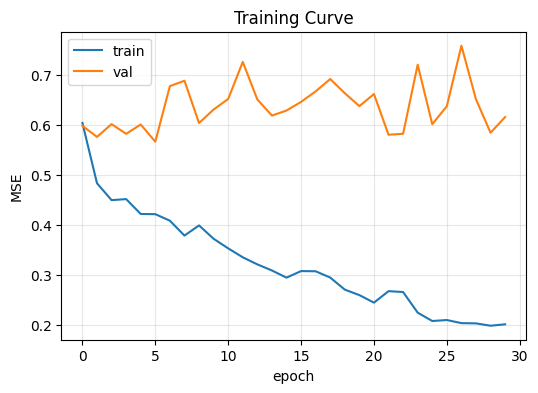

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Training Curve')
plt.show()


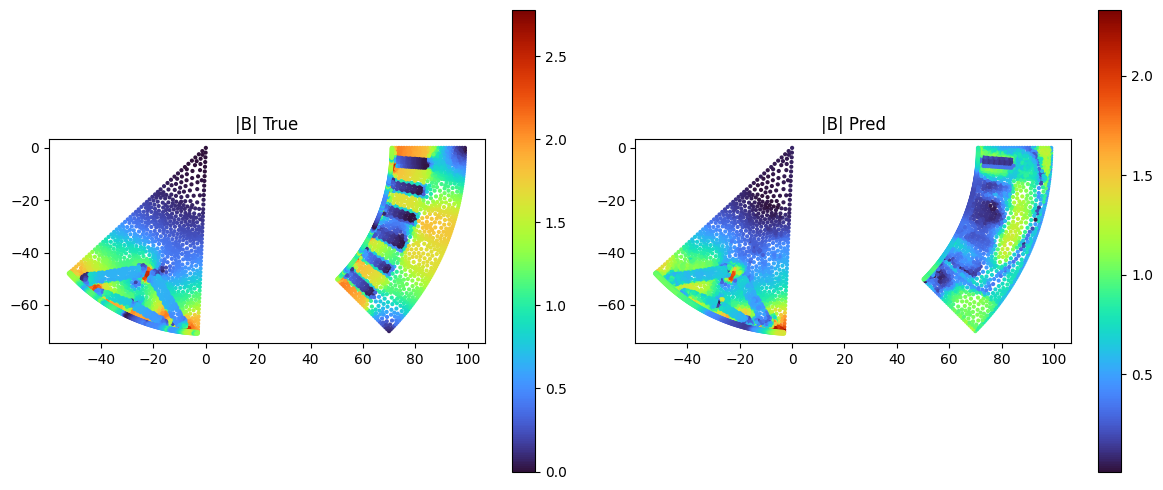

In [ ]:
# ============================================================
# 역정규화 후 실제 물리량으로 비교
# ============================================================
model.eval()
g = val_graphs[0].to(device)
with torch.no_grad():
    pred_norm = model(g.x, g.edge_attr, g).cpu()

# ★ 역정규화: pred_real = pred_norm * y_std + y_mean
pred_real = (pred_norm * y_std + y_mean).numpy()
y_real    = (g.y.cpu() * y_std + y_mean).numpy()
pos       = g.pos.cpu().numpy()

b_true = np.linalg.norm(y_real, axis=1)
b_pred = np.linalg.norm(pred_real, axis=1)
b_err  = np.abs(b_true - b_pred)

# 상대오차 (|B|>0.01 인 노드만)
mask = b_true > 0.01
rel_err = b_err[mask] / b_true[mask] * 100  # %

print(f'=== val step (원래 인덱스 {val_indices[0]}) ===')
print(f'|B| MAE:  {b_err.mean():.6f} T')
print(f'|B| RMSE: {np.sqrt((b_err**2).mean()):.6f} T')

print(f'|B|>0.01 상대오차: mean {rel_err.mean():.2f}%, median {np.median(rel_err):.2f}%, 95th {np.percentile(rel_err,95):.2f}%')

plt.show()

# 시각화: True / Pred / Errorplt.tight_layout()

vmin, vmax = 0, max(b_true.max(), b_pred.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))plt.colorbar(im2, ax=axes[2])

axes[2].set_aspect('equal')

im0 = axes[0].scatter(pos[:, 0], pos[:, 1], c=b_true, s=4, cmap='turbo', vmin=vmin, vmax=vmax)axes[2].set_title('|B| Abs Error [T]')

axes[0].set_title('|B| True [T]')im2 = axes[2].scatter(pos[:, 0], pos[:, 1], c=b_err, s=4, cmap='hot')

axes[0].set_aspect('equal')

plt.colorbar(im0, ax=axes[0])plt.colorbar(im1, ax=axes[1])

axes[1].set_aspect('equal')

im1 = axes[1].scatter(pos[:, 0], pos[:, 1], c=b_pred, s=4, cmap='turbo', vmin=vmin, vmax=vmax)axes[1].set_title('|B| Pred [T]')

In [ ]:
save_path = '/workspace/meshgraphnet_motor_bxby.pt'
torch.save({'model_state_dict': model.state_dict()}, save_path)
print('saved:', save_path)
